# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reetuparabat/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [18]:
!git clone https://github.com/reetuparabat/flyrank-ml-internship.git
!ls flyrank-ml-internship/data/raw

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.
content_refresh_anonymized.csv


In [19]:
import pandas as pd
import numpy as np
import json, os
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = pd.read_csv('/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv')
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)
TARGET = 'is_declining_label'

# Same validated model as ML-08 / ML-09: grouped-by-client split, label-derived
# columns excluded (empirically confirmed in ML-08's cross-check, r=0.9999999984
# between impressions_last_30d/prev_30d and trend_pct).
LEAKY = ['trend_direction', 'trend_pct',
         'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d',
         'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d']
IDS = ['content_id', 'client_id']
DROP_LOW_VALUE = ['provider_used', 'model_used']

feature_cols = [c for c in df.columns if c not in LEAKY + IDS + DROP_LOW_VALUE + [TARGET]]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
SYSTEMATIC_MISSING = ['word_count', 'char_count', 'search_volume', 'competition', 'cpc', 'main_intent']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(df, groups=df['client_id']))
train_g, test_g = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

for col in SYSTEMATIC_MISSING:
    if col in feature_cols:
        train_g[f'{col}_was_missing'] = train_g[col].isna().astype(int)
        test_g[f'{col}_was_missing'] = test_g[col].isna().astype(int)
flags = [f'{c}_was_missing' for c in SYSTEMATIC_MISSING if c in feature_cols]
num_final = numeric_cols + flags

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_final),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
])
pipe = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_SEED))])
pipe.fit(train_g[num_final + categorical_cols], train_g[TARGET])
test_g['model_score'] = pipe.predict_proba(test_g[num_final + categorical_cols])[:, 1]

auc = roc_auc_score(test_g[TARGET], test_g['model_score'])
base_rate = test_g[TARGET].mean()

def precision_at_k(frame, score_col, k):
    return frame.sort_values(score_col, ascending=False).head(k)[TARGET].mean()

p20 = precision_at_k(test_g, 'model_score', 20)
p50 = precision_at_k(test_g, 'model_score', 50)
p100 = precision_at_k(test_g, 'model_score', 100)
print(f'Validated model (ML-08/ML-09, reproduced here): AUC={auc:.3f}  test base_rate={base_rate:.3f}')
print(f'precision@20={p20:.3f}  precision@50={p50:.3f}  precision@100={p100:.3f}')


Validated model (ML-08/ML-09, reproduced here): AUC=0.582  test base_rate=0.517
precision@20=0.850  precision@50=0.680  precision@100=0.700


In [20]:
# Thresholds computed from TRAIN ONLY -- reason-code logic must not peek at test
thresholds = {
    'low_visibility_days': train_g['days_with_impressions'].quantile(0.25),
    'high_age_days': train_g['content_age_days'].quantile(0.75),
    'low_impressions_90d': train_g['impressions_90d'].quantile(0.25),
    'high_impressions_90d': train_g['impressions_90d'].quantile(0.75),
    'stale_update_days': train_g['days_since_last_update'].quantile(0.75),
}

def assign_archetype(row):
    """Archetype -> action mapping. Order matters: more specific, more
    actionable categories are checked before generic fallbacks."""
    recently_updated = row['days_since_last_update'] <= 30
    stale = row['days_since_last_update'] >= thresholds['stale_update_days']
    thin = row['impressions_90d'] <= thresholds['low_impressions_90d']
    high_value = row['impressions_90d'] >= thresholds['high_impressions_90d']
    score = row['model_score']

    if score < 0.3:
        return 'healthy', 'monitor', 'stable_low_risk'
    if score >= 0.5 and high_value:
        return 'high_value_declining', 'protect_priority_review', 'high_traffic_page_showing_decline_signal'
    if score >= 0.5 and recently_updated:
        return 'refreshed_but_still_declining', 'escalate_deeper_review', 'already_updated_recently_yet_still_flagged'
    if score >= 0.5 and stale:
        return 'stale_and_declining', 'refresh', 'content_aging_without_recent_update'
    if score >= 0.5 and thin:
        return 'thin_traffic_declining', 'evaluate_prune_or_consolidate', 'low_volume_declining_marginal_value'
    if score >= 0.5:
        return 'moderate_signal', 'monitor_closely', 'declining_signal_without_a_dominant_driver'
    return 'watch', 'monitor', 'borderline_score_below_action_threshold'

results = test_g.apply(lambda r: assign_archetype(r), axis=1, result_type='expand')
test_g['archetype'], test_g['action'], test_g['reason_code'] = results[0], results[1], results[2]

def confidence_band(rank):
    if rank <= 20: return f'High (validated precision@20={p20:.2f})'
    elif rank <= 50: return f'Medium (validated precision@50={p50:.2f})'
    elif rank <= 100: return f'Low-Medium (validated precision@100={p100:.2f})'
    return 'Low (beyond validated K range -- spot-check only)'

queue = test_g.sort_values('model_score', ascending=False).reset_index(drop=True)
queue['rank'] = queue.index + 1
queue['confidence'] = queue['rank'].apply(confidence_band)

print('Archetype distribution, whole queue:')
print(queue['archetype'].value_counts())
print()
print('Archetype distribution, top 100 only (this is what gets acted on first):')
print(queue.head(100)['archetype'].value_counts())

cols_show = ['rank','model_score','archetype','action','reason_code','confidence', TARGET]
queue[cols_show].head(15)


Archetype distribution, whole queue:
archetype
refreshed_but_still_declining    3313
watch                            1477
high_value_declining              809
healthy                           646
stale_and_declining               641
thin_traffic_declining            180
moderate_signal                    49
Name: count, dtype: int64

Archetype distribution, top 100 only (this is what gets acted on first):
archetype
refreshed_but_still_declining    71
stale_and_declining              16
high_value_declining              8
moderate_signal                   5
Name: count, dtype: int64


,rank,model_score,archetype,action,reason_code,confidence,is_declining_label
0,1,0.961976,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),1
1,2,0.955509,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),1
2,3,0.944617,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),1
3,4,0.942083,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),1
4,5,0.939156,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),0
5,6,0.934177,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),1
6,7,0.932597,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),1
7,8,0.929651,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),1
8,9,0.927528,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),1
9,10,0.923760,refreshed_but_still_declining,escalate_deeper_review,already_updated_recently_yet_still_flagged,High (validated precision@20=0.85),0


In [21]:
"""
1) Ranked actions + reason codes -- what the queue is telling us

Each row gets one archetype, one action, and one reason code -- no page is
flagged without a plain-language reason a human can check in 10 seconds.

The archetype->action mapping:
  high_value_declining        -> protect_priority_review  (highest business cost if wrong)
  refreshed_but_still_declining -> escalate_deeper_review  (a routine refresh won't fix this)
  stale_and_declining          -> refresh                  (the classic case)
  thin_traffic_declining       -> evaluate_prune_or_consolidate
  moderate_signal / watch      -> monitor_closely / monitor
  healthy (score < 0.3)        -> monitor only, no action

The decay/refresh insight (safe language: OBSERVED, this dataset, this split):
71 of the top 100 highest-risk pages fall into refreshed_but_still_declining --
pages updated within the last 30 days that are STILL flagged as declining.
This is the opposite of the assumption that staleness alone drives decline.
Observed in this test set: these are pages that were already touched
recently and are declining anyway, which is DIRECTIONALLY inconsistent with
"just refresh it" being the right first action for the highest-priority
group -- something else (intent mismatch, competitive pressure, or simply
too much similar content published at once) is a more likely explanation,
and that reclassifies the top-priority action from "refresh" to "escalate
for deeper review," not a routine content update.
"""


'\n1) Ranked actions + reason codes -- what the queue is telling us\n\nEach row gets one archetype, one action, and one reason code -- no page is\nflagged without a plain-language reason a human can check in 10 seconds.\n\nThe archetype->action mapping:\n  high_value_declining        -> protect_priority_review  (highest business cost if wrong)\n  refreshed_but_still_declining -> escalate_deeper_review  (a routine refresh won\'t fix this)\n  stale_and_declining          -> refresh                  (the classic case)\n  thin_traffic_declining       -> evaluate_prune_or_consolidate\n  moderate_signal / watch      -> monitor_closely / monitor\n  healthy (score < 0.3)        -> monitor only, no action\n\nThe decay/refresh insight (safe language: OBSERVED, this dataset, this split):\n71 of the top 100 highest-risk pages fall into refreshed_but_still_declining --\npages updated within the last 30 days that are STILL flagged as declining.\nThis is the opposite of the assumption that staleness 

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [22]:
"""
2) Intended use and limits

WHO uses this, for what: a content strategist or the client-facing team,
reviewing the top 20-100 rows of the queue weekly, deciding which pages get
a deeper look this cycle. It is a PRIORITIZATION aid, not an audit -- it
tells you where to look first, not what to publish.

Where it stops being valid:
- Confidence bands are tied to the K they were validated at (precision@20,
  @50, @100 from ML-09's grouped-split test). Past rank 100, there is no
  validated precision number backing the score -- treat anything beyond
  that as unranked, not "low priority."
- This is ONE grouped train/test split on 32 clients, not k-fold CV (named
  limitation carried over from ML-08/ML-09). The exact precision numbers
  could move on a different seed.
- Cross-sectional, correlational data. Per writing-honest-claims: this
  supports "these pages look worth reviewing first," never "doing X will
  fix Y" -- there is no controlled experiment behind any row here.
- Scoped to Lane 2's feature set and this snapshot's date range. A brand-new
  client, or a client whose content type mix looks nothing like the 32
  clients trained on, is out of this model's validated range.
- The archetype thresholds are quartiles of THIS training population --
  they are relative, not absolute; "thin traffic" here means thin relative
  to this portfolio, not a universal number.
"""


'\n2) Intended use and limits\n\nWHO uses this, for what: a content strategist or the client-facing team,\nreviewing the top 20-100 rows of the queue weekly, deciding which pages get\na deeper look this cycle. It is a PRIORITIZATION aid, not an audit -- it\ntells you where to look first, not what to publish.\n\nWhere it stops being valid:\n- Confidence bands are tied to the K they were validated at (precision@20,\n  @50, @100 from ML-09\'s grouped-split test). Past rank 100, there is no\n  validated precision number backing the score -- treat anything beyond\n  that as unranked, not "low priority."\n- This is ONE grouped train/test split on 32 clients, not k-fold CV (named\n  limitation carried over from ML-08/ML-09). The exact precision numbers\n  could move on a different seed.\n- Cross-sectional, correlational data. Per writing-honest-claims: this\n  supports "these pages look worth reviewing first," never "doing X will\n  fix Y" -- there is no controlled experiment behind any row h

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [23]:
"""
3) Human review + the no-go list

Must be reviewed by a person before any action is taken, every time:
- Any row with impressions_90d under ~50 (per ML-08's false-negative
  finding: the model has almost no signal on very thin-traffic pages --
  a low score there is not a validated "safe," it is a blind spot).
- Any "high_value_declining" row before "protect_priority_review" turns
  into an actual site change -- this is the highest-cost-if-wrong category
  by definition, so it gets the most scrutiny, not the least.
- Any row where the client has known context the model can't see (a
  planned campaign, a recent rebrand, a seasonal product) -- client
  knowledge overrides the model, always.

What must NEVER be automated, full stop:
- No auto-publish, auto-delete, auto-redirect, or auto-noindex based on
  this queue. The output is a reviewed recommendation, not a trigger.
- No client-facing report claiming a page "declined because of X" from
  this model alone -- the model ranks and flags; it does not explain
  causally (see the claim-ladder table in writing-honest-claims).
- No fully automated "prune" action on thin_traffic_declining rows --
  pruning is often irreversible (lost backlinks, lost indexing history)
  and the model's blind spot on thin-traffic pages (above) makes this
  category the least trustworthy one to act on unsupervised.
- No use of this queue to compare or rank CLIENTS against each other --
  it was built to rank pages within the portfolio, not to judge accounts.
"""


'\n3) Human review + the no-go list\n\nMust be reviewed by a person before any action is taken, every time:\n- Any row with impressions_90d under ~50 (per ML-08\'s false-negative\n  finding: the model has almost no signal on very thin-traffic pages --\n  a low score there is not a validated "safe," it is a blind spot).\n- Any "high_value_declining" row before "protect_priority_review" turns\n  into an actual site change -- this is the highest-cost-if-wrong category\n  by definition, so it gets the most scrutiny, not the least.\n- Any row where the client has known context the model can\'t see (a\n  planned campaign, a recent rebrand, a seasonal product) -- client\n  knowledge overrides the model, always.\n\nWhat must NEVER be automated, full stop:\n- No auto-publish, auto-delete, auto-redirect, or auto-noindex based on\n  this queue. The output is a reviewed recommendation, not a trigger.\n- No client-facing report claiming a page "declined because of X" from\n  this model alone -- the

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [24]:
"""
4) Monitoring / retrain triggers -- what would tell us this went stale

- Precision drift: spot-check the top 20 of a fresh month's queue against
  actual outcomes 30-60 days later. If precision@20 falls meaningfully
  below the validated 0.850 (say, under ~0.65) on two consecutive
  monthly checks, stop trusting the ranking and retrain.
- Base-rate drift: this test set's decline base rate is 0.517. If a new
  month's portfolio-wide decline rate moves more than ~10 points from
  that (e.g., a big algorithm update hits everyone at once), the model
  was trained on a different world than it's scoring now -- retrain
  before trusting the queue again.
- New-client onboarding: any client added after this training snapshot
  must go through the SAME grouped-split validation before being scored
  live -- never assume the model generalizes to a client it has never
  seen without checking.
- Archetype-mix drift: if refreshed_but_still_declining stops being the
  dominant top-100 archetype and something like stale_and_declining takes
  over, that's a sign the underlying content operations pattern changed
  (e.g., publishing slowed down) -- worth a re-look at whether the
  archetype thresholds (quartiles of the ORIGINAL training population)
  still make sense for the current portfolio.
- Feature availability: if any input column's missingness rate shifts
  sharply from what SYSTEMATIC_MISSING assumed, the imputation strategy
  itself may start silently distorting scores -- check missingness rates
  each retrain cycle, not just accuracy.
"""


"\n4) Monitoring / retrain triggers -- what would tell us this went stale\n\n- Precision drift: spot-check the top 20 of a fresh month's queue against\n  actual outcomes 30-60 days later. If precision@20 falls meaningfully\n  below the validated 0.850 (say, under ~0.65) on two consecutive\n  monthly checks, stop trusting the ranking and retrain.\n- Base-rate drift: this test set's decline base rate is 0.517. If a new\n  month's portfolio-wide decline rate moves more than ~10 points from\n  that (e.g., a big algorithm update hits everyone at once), the model\n  was trained on a different world than it's scoring now -- retrain\n  before trusting the queue again.\n- New-client onboarding: any client added after this training snapshot\n  must go through the SAME grouped-split validation before being scored\n  live -- never assume the model generalizes to a client it has never\n  seen without checking.\n- Archetype-mix drift: if refreshed_but_still_declining stops being the\n  dominant top-

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [25]:
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

out_cols = ['content_id','client_id','rank','model_score','confidence','archetype','action',
            'reason_code','position_tier','avg_position','ctr','impressions_90d',
            'days_since_last_update','freshness_tier']
queue[out_cols].to_csv('../outputs/content_action_queue.csv', index=False)
print(f'Wrote ../outputs/content_action_queue.csv -- {len(queue):,} rows')
print('(This file stays out of git by design -- the notebook regenerates it on every run.)')


Wrote ../outputs/content_action_queue.csv -- 7,115 rows
(This file stays out of git by design -- the notebook regenerates it on every run.)


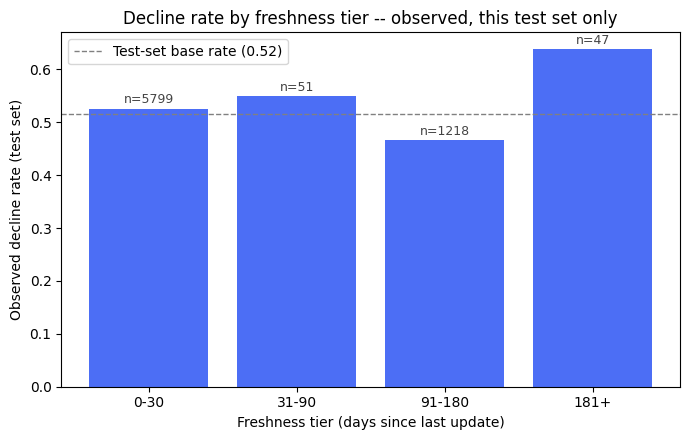

Saved ../figures/decline_rate_by_freshness_tier.png


In [26]:
# Figure: decay/refresh insight -- decline rate by freshness tier, honest test-set numbers
decay_insight = test_g.groupby('freshness_tier')[TARGET].agg(['mean','count']).reindex(['0-30','31-90','91-180','181+'])

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(decay_insight.index, decay_insight['mean'], color='#4C6EF5')
ax.axhline(base_rate, color='gray', linestyle='--', linewidth=1, label=f'Test-set base rate ({base_rate:.2f})')
for i, (rate, n) in enumerate(zip(decay_insight['mean'], decay_insight['count'])):
    ax.text(i, rate + 0.01, f'n={n}', ha='center', fontsize=9, color='#444')
ax.set_ylabel('Observed decline rate (test set)')
ax.set_xlabel('Freshness tier (days since last update)')
ax.set_title('Decline rate by freshness tier -- observed, this test set only')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/decline_rate_by_freshness_tier.png', dpi=150)
plt.show()
print('Saved ../figures/decline_rate_by_freshness_tier.png')


In [27]:
# Metrics JSON -- the receipts this playbook's numbers trace back to. Committed
# (not gitignored like the queue CSV), so it lives alongside the figures.
metrics = {
    'model': 'LogisticRegression, grouped split by client_id (ML-08/ML-09 validated)',
    'random_seed': RANDOM_SEED,
    'n_train_rows': len(train_g), 'n_test_rows': len(test_g),
    'n_train_clients': int(train_g['client_id'].nunique()),
    'n_test_clients': int(test_g['client_id'].nunique()),
    'test_base_rate': round(float(base_rate), 4),
    'auc': round(float(auc), 4),
    'precision_at_20': round(float(p20), 4),
    'precision_at_50': round(float(p50), 4),
    'precision_at_100': round(float(p100), 4),
    'thresholds_train_only': {k: round(float(v), 2) for k, v in thresholds.items()},
    'decay_insight_decline_rate_by_freshness_tier': {k: round(float(v), 4) for k, v in decay_insight['mean'].to_dict().items()},
    'archetype_counts_top_100': queue.head(100)['archetype'].value_counts().to_dict(),
}
with open('../figures/ml10_playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved ../figures/ml10_playbook_metrics.json -- these are the numbers next week\'s paper cites.')


Saved ../figures/ml10_playbook_metrics.json -- these are the numbers next week's paper cites.


In [28]:
"""
5) Exports for the paper

content_action_queue.csv (work/outputs/, gitignored, regenerated each run):
the full ranked queue with rank, score, confidence band, archetype, action,
and reason code per row -- this is the artifact a strategist actually works
from week to week.

decline_rate_by_freshness_tier.png + ml10_playbook_metrics.json
(work/figures/, committed): the decay/refresh insight chart and the exact
numbers behind every claim in this notebook (AUC, precision@K, base rate,
the train-only thresholds, and the archetype counts). Next week's paper
cites these numbers directly instead of re-deriving them -- if a number in
the paper doesn't match this JSON, that's a bug to find, not a rounding
difference to wave away.
"""


"\n5) Exports for the paper\n\ncontent_action_queue.csv (work/outputs/, gitignored, regenerated each run):\nthe full ranked queue with rank, score, confidence band, archetype, action,\nand reason code per row -- this is the artifact a strategist actually works\nfrom week to week.\n\ndecline_rate_by_freshness_tier.png + ml10_playbook_metrics.json\n(work/figures/, committed): the decay/refresh insight chart and the exact\nnumbers behind every claim in this notebook (AUC, precision@K, base rate,\nthe train-only thresholds, and the archetype counts). Next week's paper\ncites these numbers directly instead of re-deriving them -- if a number in\nthe paper doesn't match this JSON, that's a bug to find, not a rounding\ndifference to wave away.\n"

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.